# 📘 Notebook 2: Attention Mechanism from Scratch
## Building LLMs from Scratch Workshop

**Objective:** Understand and implement the attention mechanism — the core building block of Transformers.

**What you'll learn:**
1. Intuition behind attention (why it matters)
2. Simple self-attention (dot-product)
3. Scaled dot-product attention with trainable weights
4. Causal (masked) attention for autoregressive models
5. Multi-head attention
6. Visualizing attention weights

---


## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. The Intuition Behind Attention

Consider the sentence: *"The cat sat on the mat because it was tired."*

What does **"it"** refer to? A human knows "it" = "the cat". But how does a model figure this out?

**Attention** allows each token to "look at" every other token and compute a relevance score. The token "it" will assign high attention to "cat" because they're contextually related.

### The Core Idea:
For each token, compute:
1. **Query (Q):** "What am I looking for?"
2. **Key (K):** "What do I contain?"
3. **Value (V):** "What information do I provide?"

Attention score = how well a Query matches a Key.
Output = weighted sum of Values, weighted by attention scores.

Let's build this step by step.


## 3. Simple Self-Attention (No Learned Parameters)

The simplest attention: just compute dot products between token embeddings.

$$\text{attention}(x_i) = \sum_j \frac{x_i \cdot x_j}{\sum_k x_i \cdot x_k} \cdot x_j$$


In [2]:
# Create a simple input: 4 tokens, each with 3-dimensional embeddings
# Think of this as 4 words, each represented by a 3D vector

# Simulated embeddings for: ["The", "cat", "is", "smart"]
inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # "The"
    [0.55, 0.87, 0.66],  # "cat"
    [0.57, 0.85, 0.64],  # "is"
    [0.22, 0.58, 0.33],  # "smart"
])

print("Input embeddings shape:", inputs.shape)
print("(4 tokens, 3-dimensional embeddings)")
print()

# Step 1: Compute attention scores (dot products)
# Each token computes dot product with every other token
attn_scores = inputs @ inputs.T  # [4, 4]
print("Attention scores (raw dot products):")
print(attn_scores)
print()

# Step 2: Normalize with softmax to get attention weights
# Each row sums to 1 — it's a probability distribution
attn_weights = F.softmax(attn_scores, dim=-1)
print("Attention weights (after softmax):")
print(attn_weights)
print(f"Row sums: {attn_weights.sum(dim=-1)}")  # Should all be 1.0
print()

# Step 3: Compute context vectors (weighted sum of values)
context = attn_weights @ inputs  # [4, 4] x [4, 3] = [4, 3]
print("Context vectors (output of attention):")
print(context)
print(f"Shape: {context.shape} — same shape as input!")
print()
print("Each output token is now a weighted combination of ALL input tokens.")
print("Tokens that are more 'relevant' contribute more to each output.")


Input embeddings shape: torch.Size([4, 3])
(4 tokens, 3-dimensional embeddings)

Attention scores (raw dot products):
tensor([[0.9995, 0.9544, 0.9422, 0.4753],
        [0.9544, 1.4950, 1.4754, 0.8434],
        [0.9422, 1.4754, 1.4570, 0.8296],
        [0.4753, 0.8434, 0.8296, 0.4937]])

Attention weights (after softmax):
tensor([[0.2863, 0.2737, 0.2704, 0.1695],
        [0.1888, 0.3242, 0.3179, 0.1690],
        [0.1897, 0.3233, 0.3174, 0.1695],
        [0.2046, 0.2956, 0.2915, 0.2084]])
Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000])

Context vectors (output of attention):
tensor([[0.4651, 0.6093, 0.6645],
        [0.4779, 0.6787, 0.6413],
        [0.4776, 0.6779, 0.6413],
        [0.4625, 0.6565, 0.6325]])
Shape: torch.Size([4, 3]) — same shape as input!

Each output token is now a weighted combination of ALL input tokens.
Tokens that are more 'relevant' contribute more to each output.


## 4. Trainable Self-Attention (Q, K, V Projections)

The simple version above has no learnable parameters. In a real Transformer, we project inputs through **learned weight matrices** to create Q, K, V:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ scaling prevents dot products from becoming too large.


In [3]:
class SelfAttention(nn.Module):
    """
    Single-head self-attention with trainable Q, K, V projections.
    
    Args:
        d_in:  Input embedding dimension
        d_out: Output dimension (also the dimension of Q, K, V)
    """
    
    def __init__(self, d_in, d_out):
        super().__init__()
        # Trainable weight matrices for Q, K, V
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        self.d_out = d_out
    
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape [batch_size, seq_len, d_in]
               or [seq_len, d_in] for unbatched input
        
        Returns:
            context: Output tensor of shape [..., seq_len, d_out]
            attn_weights: Attention weights of shape [..., seq_len, seq_len]
        """
        # Project inputs to Q, K, V
        Q = self.W_query(x)  # [..., seq_len, d_out]
        K = self.W_key(x)    # [..., seq_len, d_out]
        V = self.W_value(x)  # [..., seq_len, d_out]
        
        # Compute scaled dot-product attention scores
        # Q @ K^T gives [seq_len, seq_len] attention matrix
        attn_scores = Q @ K.transpose(-2, -1)  # [..., seq_len, seq_len]
        
        # Scale by sqrt(d_k) to prevent large values
        attn_scores = attn_scores / (self.d_out ** 0.5)
        
        # Softmax to get attention weights (rows sum to 1)
        attn_weights = F.softmax(attn_scores, dim=-1)
        
        # Weighted sum of values
        context = attn_weights @ V  # [..., seq_len, d_out]
        
        return context, attn_weights

# Test it
d_in, d_out = 3, 4  # Input dim=3, output dim=4
attn = SelfAttention(d_in, d_out)

context, weights = attn(inputs)
print(f"Input shape:            {inputs.shape}")
print(f"Context output shape:   {context.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"\nAttention weights (each row sums to 1):")
print(weights.detach())
print(f"Row sums: {weights.sum(dim=-1).detach()}")


Input shape:            torch.Size([4, 3])
Context output shape:   torch.Size([4, 4])
Attention weights shape: torch.Size([4, 4])

Attention weights (each row sums to 1):
tensor([[0.2370, 0.2556, 0.2550, 0.2524],
        [0.2455, 0.2569, 0.2563, 0.2413],
        [0.2451, 0.2572, 0.2566, 0.2411],
        [0.2504, 0.2526, 0.2523, 0.2448]])
Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000])


## 5. Causal (Masked) Self-Attention

For **autoregressive** language models (like GPT), each token should only attend to **previous** tokens, not future ones. This is called **causal masking**.

We apply a triangular mask to the attention scores before softmax:

```
Before masking:        After masking:
[0.5  0.3  0.1  0.1]  [0.5  -inf -inf -inf]
[0.2  0.6  0.1  0.1]  [0.2  0.6  -inf -inf]
[0.1  0.3  0.4  0.2]  [0.1  0.3  0.4  -inf]
[0.3  0.2  0.2  0.3]  [0.3  0.2  0.2  0.3 ]
```

After softmax, `-inf` becomes 0, so future tokens get zero attention.


In [4]:
class CausalSelfAttention(nn.Module):
    """
    Causal (masked) self-attention.
    Each token can only attend to itself and previous tokens.
    This is what GPT uses!
    
    Args:
        d_in:  Input embedding dimension
        d_out: Output dimension
        context_length: Maximum sequence length (for creating the mask)
        dropout: Dropout rate for attention weights
    """
    
    def __init__(self, d_in, d_out, context_length, dropout=0.0):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        self.d_out = d_out
        self.dropout = nn.Dropout(dropout)
        
        # Register the causal mask as a buffer (not a parameter)
        # This creates a lower-triangular matrix of ones
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        # Register as buffer so it moves with the model to GPU/CPU
        self.register_buffer('mask', mask.bool())
    
    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len, d_in]
        
        Returns:
            context: [batch_size, seq_len, d_out]
            attn_weights: [batch_size, seq_len, seq_len]
        """
        batch_size, seq_len, _ = x.shape
        
        Q = self.W_query(x)
        K = self.W_key(x)
        V = self.W_value(x)
        
        # Compute attention scores
        attn_scores = Q @ K.transpose(-2, -1) / (self.d_out ** 0.5)
        
        # Apply causal mask: set future positions to -infinity
        # We use the pre-computed mask, sliced to current seq_len
        attn_scores.masked_fill_(
            self.mask[:seq_len, :seq_len],  # True where we want to mask
            float('-inf')
        )
        
        # Softmax (masked positions become 0)
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Weighted sum of values
        context = attn_weights @ V
        
        return context, attn_weights

# Test it
context_length = 8
causal_attn = CausalSelfAttention(d_in=3, d_out=4, context_length=context_length)

# Need batch dimension: [batch=1, seq_len=4, d_in=3]
batched_input = inputs.unsqueeze(0)
context, weights = causal_attn(batched_input)

print(f"Input shape:             {batched_input.shape}")
print(f"Context output shape:    {context.shape}")
print(f"\nCausal attention weights:")
print(weights[0].detach().numpy().round(3))
print(f"\nNotice: upper triangle is all zeros (no future attention)!")
print(f"Row 0 attends only to position 0")
print(f"Row 1 attends to positions 0 and 1")
print(f"Row 3 attends to positions 0, 1, 2, and 3")


Input shape:             torch.Size([1, 4, 3])
Context output shape:    torch.Size([1, 4, 4])

Causal attention weights:
[[1.    0.    0.    0.   ]
 [0.475 0.525 0.    0.   ]
 [0.312 0.344 0.345 0.   ]
 [0.24  0.254 0.255 0.251]]

Notice: upper triangle is all zeros (no future attention)!
Row 0 attends only to position 0
Row 1 attends to positions 0 and 1
Row 3 attends to positions 0, 1, 2, and 3


## 6. Multi-Head Attention

Instead of one attention operation, we run **multiple attention heads in parallel**, each learning different patterns:

- **Head 1** might learn syntactic relationships
- **Head 2** might learn semantic relationships
- **Head 3** might learn positional patterns

Each head has its own Q, K, V weights. Outputs are concatenated and projected.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$


In [5]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Causal Self-Attention.
    
    This is the EXACT attention mechanism used in GPT models.
    
    Args:
        d_in:  Input embedding dimension
        d_out: Total output dimension (split across heads)
        context_length: Maximum sequence length
        num_heads: Number of attention heads
        dropout: Dropout rate
    """
    
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.0):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Dimension per head
        
        # Single large projections (more efficient than separate per-head)
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        
        # Output projection: combines all heads
        self.out_proj = nn.Linear(d_out, d_out, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        # Causal mask
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.register_buffer('mask', mask.bool())
    
    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len, d_in]
        
        Returns:
            output: [batch_size, seq_len, d_out]
            attn_weights: [batch_size, num_heads, seq_len, seq_len]
        """
        batch_size, seq_len, _ = x.shape
        
        # Step 1: Linear projections
        Q = self.W_query(x)  # [B, T, d_out]
        K = self.W_key(x)
        V = self.W_value(x)
        
        # Step 2: Reshape for multi-head: [B, T, d_out] -> [B, T, H, D] -> [B, H, T, D]
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        # Now: [B, H, T, D] where H=num_heads, D=head_dim
        
        # Step 3: Scaled dot-product attention per head
        attn_scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        # attn_scores: [B, H, T, T]
        
        # Step 4: Apply causal mask
        attn_scores.masked_fill_(
            self.mask[:seq_len, :seq_len].unsqueeze(0).unsqueeze(0),
            float('-inf')
        )
        
        # Step 5: Softmax + dropout
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Step 6: Weighted sum of values
        context = attn_weights @ V  # [B, H, T, D]
        
        # Step 7: Concatenate heads: [B, H, T, D] -> [B, T, H, D] -> [B, T, d_out]
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_out)
        
        # Step 8: Output projection
        output = self.out_proj(context)
        
        return output, attn_weights

# Test multi-head attention
d_in = 3
d_out = 8  # Must be divisible by num_heads
num_heads = 2
context_length = 16

mha = MultiHeadAttention(d_in, d_out, context_length, num_heads)

# Input: [batch=2, seq_len=4, d_in=3]
batch_input = torch.randn(2, 4, d_in)
output, attn_weights = mha(batch_input)

print(f"Input shape:            {batch_input.shape}")
print(f"Output shape:           {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"  = [batch, heads, seq_len, seq_len]")
print()

# Count parameters
total_params = sum(p.numel() for p in mha.parameters())
print(f"Total parameters in MultiHeadAttention: {total_params:,}")
print(f"  W_query: {d_in * d_out}")
print(f"  W_key:   {d_in * d_out}")
print(f"  W_value: {d_in * d_out}")
print(f"  out_proj: {d_out * d_out}")


Input shape:            torch.Size([2, 4, 3])
Output shape:           torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 2, 4, 4])
  = [batch, heads, seq_len, seq_len]

Total parameters in MultiHeadAttention: 136
  W_query: 24
  W_key:   24
  W_value: 24
  out_proj: 64


## 7. Visualizing Attention Weights

Visualizing attention helps understand what the model has learned.


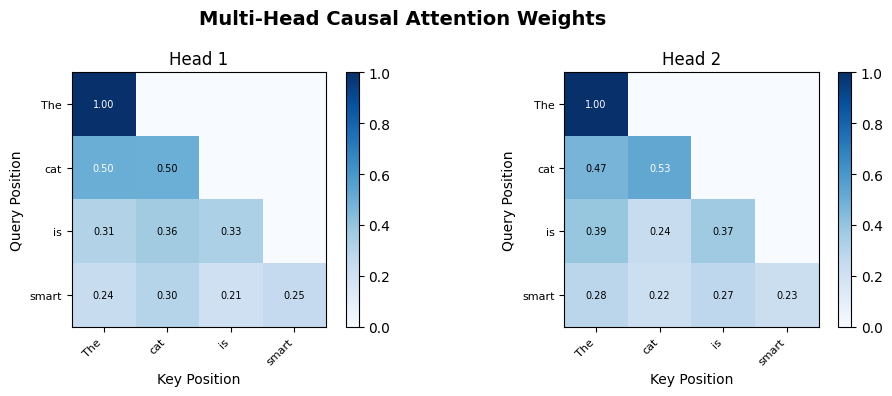

In [7]:
def plot_attention_weights(attn_weights, tokens=None, title="Attention Weights"):
    """
    Visualize attention weights as heatmaps.
    
    Args:
        attn_weights: [num_heads, seq_len, seq_len] or [seq_len, seq_len]
        tokens: List of token labels
        title: Plot title
    """
    if attn_weights.dim() == 2:
        attn_weights = attn_weights.unsqueeze(0)
    
    num_heads = attn_weights.shape[0]
    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 4))
    
    if num_heads == 1:
        axes = [axes]
    
    for h in range(num_heads):
        ax = axes[h]
        w = attn_weights[h].detach().numpy()
        
        im = ax.imshow(w, cmap='Blues', vmin=0, vmax=w.max())
        ax.set_title(f'Head {h + 1}')
        ax.set_xlabel('Key Position')
        ax.set_ylabel('Query Position')
        
        if tokens:
            ax.set_xticks(range(len(tokens)))
            ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
            ax.set_yticks(range(len(tokens)))
            ax.set_yticklabels(tokens, fontsize=8)
        
        # Add value annotations
        for i in range(w.shape[0]):
            for j in range(w.shape[1]):
                if w[i, j] > 0.01:
                    ax.text(j, i, f'{w[i,j]:.2f}', ha='center', va='center', 
                           fontsize=7, color='white' if w[i,j] > 0.5 else 'black')
        
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\attention_weights.png', dpi=100, bbox_inches='tight')
    plt.show()

# Visualize attention from our multi-head attention
tokens = ["The", "cat", "is", "smart"]
plot_attention_weights(
    attn_weights[0],  # First batch item, shape [num_heads, seq_len, seq_len]
    tokens=tokens,
    title="Multi-Head Causal Attention Weights"
)


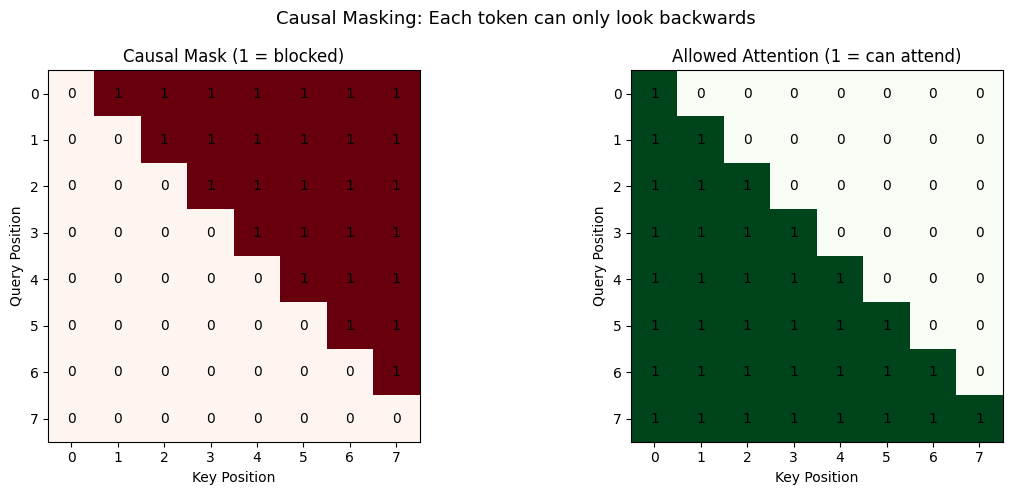

In [8]:
# Visualize the causal mask itself
seq_len = 8
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
allowed = 1 - mask  # Invert: 1 where attention is allowed

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mask
axes[0].imshow(mask.numpy(), cmap='Reds', vmin=0, vmax=1)
axes[0].set_title('Causal Mask (1 = blocked)')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, int(mask[i,j].item()), ha='center', va='center', fontsize=10)

# Allowed attention
axes[1].imshow(allowed.numpy(), cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Allowed Attention (1 = can attend)')
axes[1].set_xlabel('Key Position')
axes[1].set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        axes[1].text(j, i, int(allowed[i,j].item()), ha='center', va='center', fontsize=10)

plt.suptitle('Causal Masking: Each token can only look backwards', fontsize=13)
plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\causal_mask.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Complete Attention Module (Ready for GPT)

Let's create the final version that we'll use in our GPT model.


In [9]:
class CausalMultiHeadAttention(nn.Module):
    """
    Production-ready Multi-Head Causal Attention for GPT.
    
    This is the version we'll use in our GPT model in Notebook 3.
    Includes: Q/K/V projections, causal mask, dropout, output projection.
    
    Args:
        config: dict with keys:
            - emb_dim: Embedding dimension
            - num_heads: Number of attention heads
            - context_length: Maximum sequence length
            - drop_rate: Dropout rate
    """
    
    def __init__(self, config):
        super().__init__()
        emb_dim = config['emb_dim']
        num_heads = config['num_heads']
        context_length = config['context_length']
        drop_rate = config.get('drop_rate', 0.0)
        
        assert emb_dim % num_heads == 0, "emb_dim must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        
        self.qkv_proj = nn.Linear(emb_dim, 3 * emb_dim, bias=False)  # Combined QKV
        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=False)
        self.attn_dropout = nn.Dropout(drop_rate)
        self.resid_dropout = nn.Dropout(drop_rate)
        
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.register_buffer('mask', mask.bool())
    
    def forward(self, x, return_attn=False):
        B, T, C = x.shape
        
        # Combined QKV projection (more efficient than separate)
        qkv = self.qkv_proj(x)  # [B, T, 3*C]
        Q, K, V = qkv.chunk(3, dim=-1)  # Each: [B, T, C]
        
        # Reshape for multi-head
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention
        attn_scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        attn_scores.masked_fill_(self.mask[:T, :T].unsqueeze(0).unsqueeze(0), float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        
        context = attn_weights @ V
        context = context.transpose(1, 2).contiguous().view(B, T, C)
        output = self.resid_dropout(self.out_proj(context))
        
        if return_attn:
            return output, attn_weights
        return output

# Test the final module
config = {
    'emb_dim': 64,
    'num_heads': 4,
    'context_length': 32,
    'drop_rate': 0.1
}

final_attn = CausalMultiHeadAttention(config)
test_input = torch.randn(2, 16, 64)  # [batch=2, seq=16, emb=64]
output = final_attn(test_input)

print(f"Input:  {test_input.shape}")
print(f"Output: {output.shape}")
print(f"\nParameters: {sum(p.numel() for p in final_attn.parameters()):,}")
print(f"\nThis module is ready for our GPT model in Notebook 3!")


Input:  torch.Size([2, 16, 64])
Output: torch.Size([2, 16, 64])

Parameters: 16,384

This module is ready for our GPT model in Notebook 3!


## 9. Exercises for Students

### Exercise 1: Attention Score Analysis
Modify the `SelfAttention` class to also return the raw attention scores (before softmax).
Compare the distribution of raw scores vs. weights after softmax.

### Exercise 2: Impact of Scaling
1. Remove the `/ sqrt(d_k)` scaling
2. Train a small model with and without scaling
3. Plot the attention weight distributions — what happens without scaling?

### Exercise 3: Number of Heads
Experiment with different numbers of heads (1, 2, 4, 8) keeping `d_out` fixed.
What changes in the attention patterns?

### Exercise 4: Cross-Attention
Modify `MultiHeadAttention` to support **cross-attention** where Q comes from one sequence and K, V come from another. This is used in encoder-decoder models.

---

## 🎯 Interview Questions

1. **Why do we scale by sqrt(d_k)?**
   - Large dot products push softmax into saturated regions with near-zero gradients. Scaling keeps values in a range where softmax gradients are useful.

2. **Why is causal masking needed?**
   - In autoregressive generation, the model predicts one token at a time. During training, causal masking simulates this by preventing tokens from "cheating" by looking at future tokens.

3. **Why multiple heads instead of one large attention?**
   - Multiple heads can attend to information from different representation subspaces at different positions. One head tends to average over different attention patterns.

4. **What's the computational complexity of self-attention?**
   - O(n² · d) where n is sequence length and d is embedding dimension. This quadratic cost in n is why context length is limited.

5. **What is the output projection for?**
   - It combines information from all attention heads into a coherent representation. Without it, head outputs are just concatenated without interaction.

---

## 🐛 Common Bugs & Fixes

| Bug | Fix |
|-----|-----|
| `NaN` in attention weights | Check for all-masked rows; add small epsilon before softmax |
| Wrong mask orientation | `triu` with `diagonal=1` masks future; verify with print |
| Shape mismatch in multi-head | Ensure `d_out % num_heads == 0` |
| Attention weights don't sum to 1 | Check softmax `dim` parameter (should be `dim=-1`) |
| GPU OOM with long sequences | Reduce `context_length` or `batch_size` |

---

## ✅ Summary

In this notebook we:
1. ✅ Built simple self-attention from scratch
2. ✅ Added trainable Q, K, V projections
3. ✅ Implemented causal masking for autoregressive models
4. ✅ Built multi-head attention with combined QKV projection
5. ✅ Visualized attention weights and causal masks
6. ✅ Created a production-ready attention module for our GPT model

**Next: Notebook 3 — GPT Model Implementation →**
